# Scaled Dot-Product Attention

Self-attention builds a context-dependent representation for each token by comparing a query with the keys at allowed positions and using the resulting weights to combine value vectors. In scaled dot-product attention, this is written as `softmax(QKᵀ / √dₖ)V`.

Using a small, fixed random example, this notebook makes the score matrix, attention weights, and context vectors visible. We first allow every position to attend to every other position, then add the causal mask that a decoder-only language model uses for next-token prediction. Because the projections are untrained, the weights demonstrate the computation rather than learned word relationships.

## From projections to context vectors

The input has shape `[batch, tokens, model width]`. Three learned linear projections produce queries, keys, and values. Comparing every query with every key produces one score for each query-key pair. Softmax normalizes the scores across keys, so each row of weights sums to one before it combines the value vectors.

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

torch.manual_seed(7)
BATCH, TOKENS, D_MODEL, D_K = 1, 5, 16, 64
token_labels = ["The", "model", "predicts", "next", "tokens"]
embeddings = torch.randn(BATCH, TOKENS, D_MODEL)
q_projection = torch.nn.Linear(D_MODEL, D_K, bias=False)
k_projection = torch.nn.Linear(D_MODEL, D_K, bias=False)
v_projection = torch.nn.Linear(D_MODEL, D_K, bias=False)


In [2]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """Return context vectors, attention weights, and scaled scores."""
    scores = query @ key.transpose(-2, -1) / math.sqrt(query.size(-1))
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ value, weights, scores


## 1. Unmasked attention

Without a mask, every query position can assign weight to every key position. For a sequence of length `n`, the score tensor has an `n × n` matrix for each batch item and head. Dense attention therefore has quadratic sequence-length memory growth and roughly quadratic sequence-dependent compute.

### Compute a first attention matrix

The next cell applies the three projections and runs the attention function. It checks that the score matrix contains one score for each query-key pair, that the context vectors retain one vector per token, and that each row of weights is normalized.

In [3]:
q = q_projection(embeddings)
k = k_projection(embeddings)
v = v_projection(embeddings)
context, weights, scores = scaled_dot_product_attention(q, k, v)

print("Q/K/V shapes:", q.shape, k.shape, v.shape)
print("score shape:", scores.shape, f"= {TOKENS} x {TOKENS} scores per batch item")
print("context shape:", context.shape)
print("unmasked weights for the first query:", weights[0, 0].round(decimals=3))
assert context.shape == (BATCH, TOKENS, D_K)
assert scores.shape == (BATCH, TOKENS, TOKENS)
assert torch.allclose(weights.sum(-1), torch.ones(BATCH, TOKENS))


Q/K/V shapes: torch.Size([1, 5, 64]) torch.Size([1, 5, 64]) torch.Size([1, 5, 64])
score shape: torch.Size([1, 5, 5]) = 5 x 5 scores per batch item
context shape: torch.Size([1, 5, 64])
unmasked weights for the first query: tensor([0.1250, 0.1490, 0.1420, 0.3430, 0.2410], grad_fn=<RoundBackward1>)


### Why scale the scores?

As the query and key width grows, their dot products tend to have a larger spread. Dividing by `√dₖ` keeps those scores in a range where softmax is less likely to become extremely concentrated. The comparison below uses the same projections with and without that scaling.

In [4]:
unscaled_scores = q @ k.transpose(-2, -1)
unscaled_weights = F.softmax(unscaled_scores, dim=-1)
scaled_entropy = -(weights * weights.log()).sum(dim=-1).mean()
unscaled_entropy = -(unscaled_weights * unscaled_weights.log()).sum(dim=-1).mean()

print(f"score standard deviation: unscaled={unscaled_scores.std():.3f}, scaled={scores.std():.3f}")
print(f"mean attention entropy: unscaled={unscaled_entropy:.3f}, scaled={scaled_entropy:.3f}")
print("Dividing by sqrt(d_k) keeps dot products smaller, making softmax less likely to saturate.")


score standard deviation: unscaled=2.785, scaled=0.348
mean attention entropy: unscaled=0.785, scaled=1.564
Dividing by sqrt(d_k) keeps dot products smaller, making softmax less likely to saturate.


### Inspect the weight matrix

Rows correspond to query positions and columns to key positions. In this unmasked example, every cell is available. The colors show how this particular random initialization distributes each query's weight over the keys.

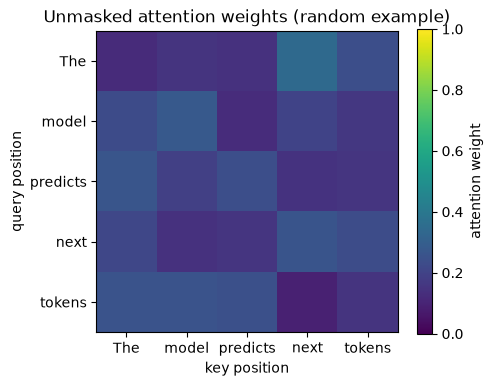

In [5]:
plt.figure(figsize=(5, 4))
plt.imshow(weights[0].detach(), vmin=0, vmax=1, cmap="viridis")
plt.xticks(range(TOKENS), token_labels)
plt.yticks(range(TOKENS), token_labels)
plt.xlabel("key position")
plt.ylabel("query position")
plt.title("Unmasked attention weights (random example)")
plt.colorbar(label="attention weight")
plt.tight_layout()
plt.show()


## 2. Causal attention for next-token prediction

A causal mask allows position *t* to use itself and earlier positions, but not later ones. This lets all positions be processed in parallel during training while preserving autoregressive next-token prediction. A padding mask solves a different problem: it excludes placeholder positions that are not part of a shorter sequence.

In [6]:
causal_mask = torch.ones(TOKENS, TOKENS, dtype=torch.bool).tril().unsqueeze(0)
causal_context, causal_weights, causal_scores = scaled_dot_product_attention(q, k, v, causal_mask)
print("causal weights for the final query:", causal_weights[0, -1].round(decimals=3))
print("future-position weights are zero:", causal_weights[0, 0, 1:].tolist())
assert causal_context.shape == (BATCH, TOKENS, D_K)
assert torch.allclose(causal_weights.sum(-1), torch.ones(BATCH, TOKENS))
assert torch.all(causal_weights.masked_select(~causal_mask) == 0)


causal weights for the final query: tensor([0.2580, 0.2540, 0.2430, 0.0940, 0.1520], grad_fn=<RoundBackward1>)
future-position weights are zero: [0.0, 0.0, 0.0, 0.0]


## From one attention computation to a Transformer block

This notebook uses one attention computation. A Transformer applies several attention heads in parallel, adds positional information, and places attention inside residual and feed-forward sublayers. The next notebook assembles those pieces into a compact decoder-only block.